# Stage 1: Gene Expression in Cancer vs. Normal Tissue

**Dataset**: RNA-seq gene expression data from the UCI ML / Kaggle TCGA (The Cancer Genome Atlas) — specifically the gene expression cancer RNA-Seq dataset.

**Goal**: Explore whether gene expression patterns from RNA-seq data can distinguish between different cancer types, and identify candidate biomarker genes that show the strongest separation across cancer subtypes.

In [59]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

In [ ]:
genes_df = pd.read_csv('/Users/meschacolongo/gene-expression-analysis/data/data.csv')
labels_df = pd.read_csv('/Users/meschacolongo/gene-expression-analysis/data/labels.csv') 

# 1. Rename and assign to NEW variables (or overwrite the old ones)
gene_df = genes_df.rename(columns={'Unnamed: 0': 'Sample_id'})
label_df = labels_df.rename(columns={'Unnamed: 0': 'Sample_id'})

# 2. Merge the dataframes
df = pd.merge(gene_df, label_df, on='Sample_id', how='left')

# 3. Set the index
df = df.set_index('Sample_id')

In [61]:
df.head()

,gene_0,gene_1,gene_2,gene_3,gene_4,gene_5,gene_6,gene_7,gene_8,gene_9,...,gene_20522,gene_20523,gene_20524,gene_20525,gene_20526,gene_20527,gene_20528,gene_20529,gene_20530,Class
Sample_id,,,,,,,,,,,,,,,,,,,,,
sample_0,0.0,2.017209,3.265527,5.478487,10.431999,0.0,7.175175,0.591871,0.0,0.0,...,8.210257,9.723516,7.220030,9.119813,12.003135,9.650743,8.921326,5.286759,0.0,PRAD
sample_1,0.0,0.592732,1.588421,7.586157,9.623011,0.0,6.816049,0.000000,0.0,0.0,...,7.323865,9.740931,6.256586,8.381612,12.674552,10.517059,9.397854,2.094168,0.0,LUAD
sample_2,0.0,3.511759,4.327199,6.881787,9.870730,0.0,6.972130,0.452595,0.0,0.0,...,8.127123,10.908640,5.401607,9.911597,9.045255,9.788359,10.090470,1.683023,0.0,PRAD
sample_3,0.0,3.663618,4.507649,6.659068,10.196184,0.0,7.843375,0.434882,0.0,0.0,...,8.792959,10.141520,8.942805,9.601208,11.392682,9.694814,9.684365,3.292001,0.0,PRAD
sample_4,0.0,2.655741,2.821547,6.539454,9.738265,0.0,6.566967,0.360982,0.0,0.0,...,8.891425,10.373790,7.181162,9.846910,11.922439,9.217749,9.461191,5.110372,0.0,BRCA


In [62]:
df.isnull().sum()

gene_0        0
gene_1        0
gene_2        0
gene_3        0
gene_4        0
             ..
gene_20527    0
gene_20528    0
gene_20529    0
gene_20530    0
Class         0
Length: 20532, dtype: int64

In [63]:
df['Class'].value_counts()

Class
BRCA    300
KIRC    146
LUAD    141
PRAD    136
COAD     78
Name: count, dtype: int64

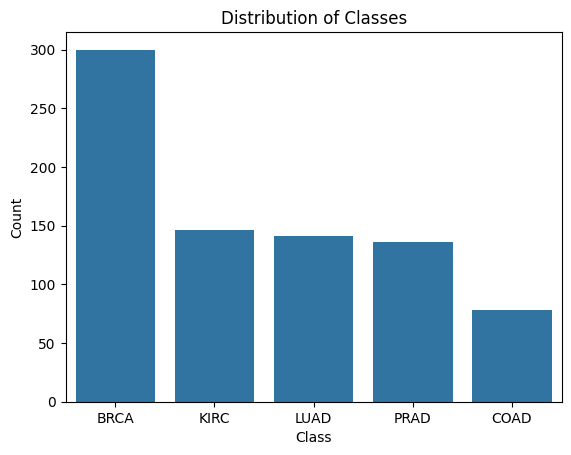

In [64]:
sns.countplot(x='Class', data=df, order=df['Class'].value_counts().index)
plt.title('Distribution of Classes')
plt.xlabel('Class')
plt.ylabel('Count')
plt.savefig('/Users/meschacolongo/gene-expression-analysis/pictures/class_distribution.png')
plt.show()

### Data Quality 

There are no missing values in this dataset. This dataset also shows an imbalance in class distribution, with BRCA (breast cancer) being significantly overrepresented compared to other cancer types such as COAD. 

This imbalance is highly due to the higher availability of the data on breast cancer in large genomic dataset such as *The Cancer Genome Atlas*, where breast cancer has been extensively studied due to its high global prevalence and clinical importance. Such class imbalance may introduce bias in downstream analysis and machine learning models, potentially leading to better performance on the majority class (BRCA) while underperforming on minority classes.

In [65]:
# 1. Separate features and target
X = df.drop(columns=['Class'])
y = df['Class']

# 2. Compute variance for each gene
variances = X.var()

# 3. Select top 20 most variable genes
top_20_genes = variances.sort_values(ascending=False).head(20).index

# 4. Filter dataset
X_top20 = X[top_20_genes]

# 5. Create new dataframe with selected genes and target
df_top20 = X_top20.copy()
df_top20['Class'] = y

# 6. Check result
print("Selected genes:", top_20_genes)
print("New shape:", X_top20.shape)

Selected genes: Index(['gene_9176', 'gene_9175', 'gene_15898', 'gene_15301', 'gene_15589',
       'gene_3540', 'gene_19661', 'gene_3541', 'gene_11250', 'gene_15897',
       'gene_439', 'gene_8014', 'gene_15896', 'gene_4773', 'gene_19236',
       'gene_16283', 'gene_9177', 'gene_3461', 'gene_8891', 'gene_2844'],
      dtype='str')
New shape: (801, 20)


### Variance Filtering

To reduce dimensionality in a dataset containing over 20,000 genes, the top 20 most variable genes were selected based on their variance across all samples. 

Highly variable genes are more likely to capture meaningful biological differences between cancer types, as they reflect significant changes in expression rather than background noise. This step helps focus the analysis on the most informative features while improving computational efficiency.

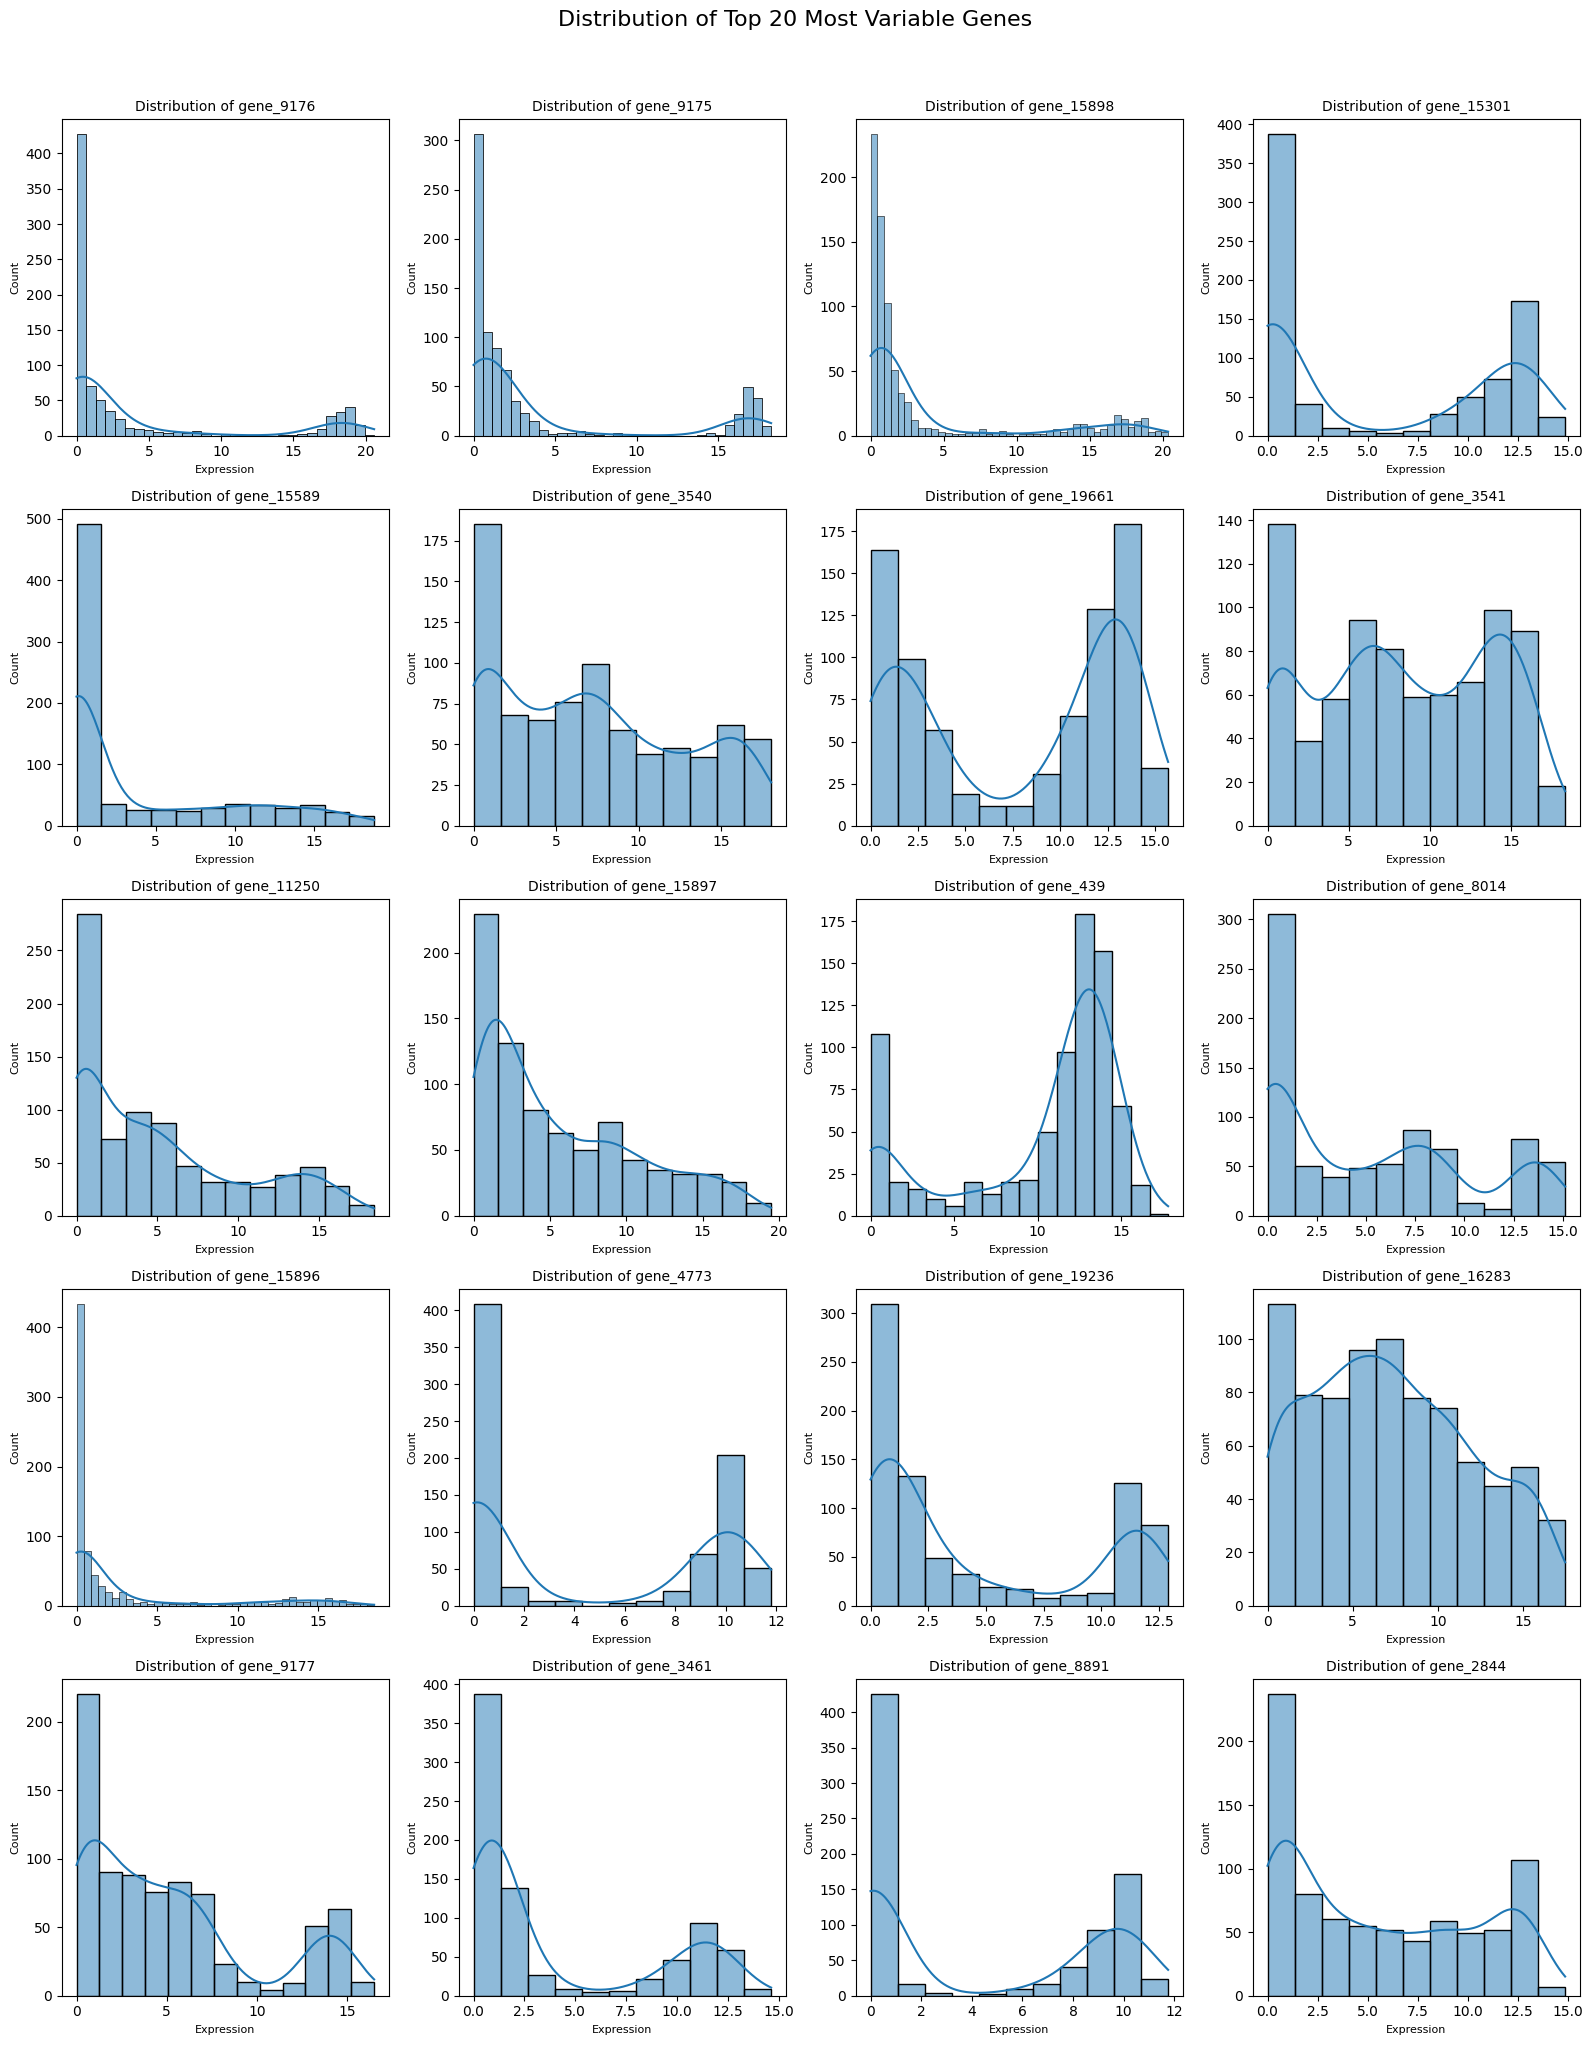

In [66]:
fig, axes = plt.subplots(nrows=5, ncols=4, figsize=(16, 20))
axes = axes.flatten()

for i, gene in enumerate(top_20_genes):
    sns.histplot(data=df_top20, x=gene, kde=True, ax=axes[i])
    
    axes[i].set_title(f'Distribution of {gene}', fontsize=10)
    axes[i].set_xlabel('Expression', fontsize=8)
    axes[i].set_ylabel('Count', fontsize=8)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)
    
plt.suptitle('Distribution of Top 20 Most Variable Genes', fontsize=16, y=1.02)    
plt.tight_layout()  
plt.savefig('/Users/meschacolongo/gene-expression-analysis/pictures/top20_gene_distributions.png', bbox_inches='tight')
plt.show()

### Distribution findings 

The histograms reveal that most gene expression distributions are right-skewed, which is consistent with the typical log-normal behavior of RNA-seq data. This indicates that the majority of genes are lowly expressed, while a smaller subset shows high expression levels.
Additionally, some genes exhibit bimodal or even trimodal distributions, suggesting that their expression levels vary across different cancer types. This may indicate that these genes have potential discriminative power for classification tasks.
Notably, genes such as Gene_3540, Gene_3541, and Gene_16283 appear to have higher expression levels compared to others and may warrant further investigation.

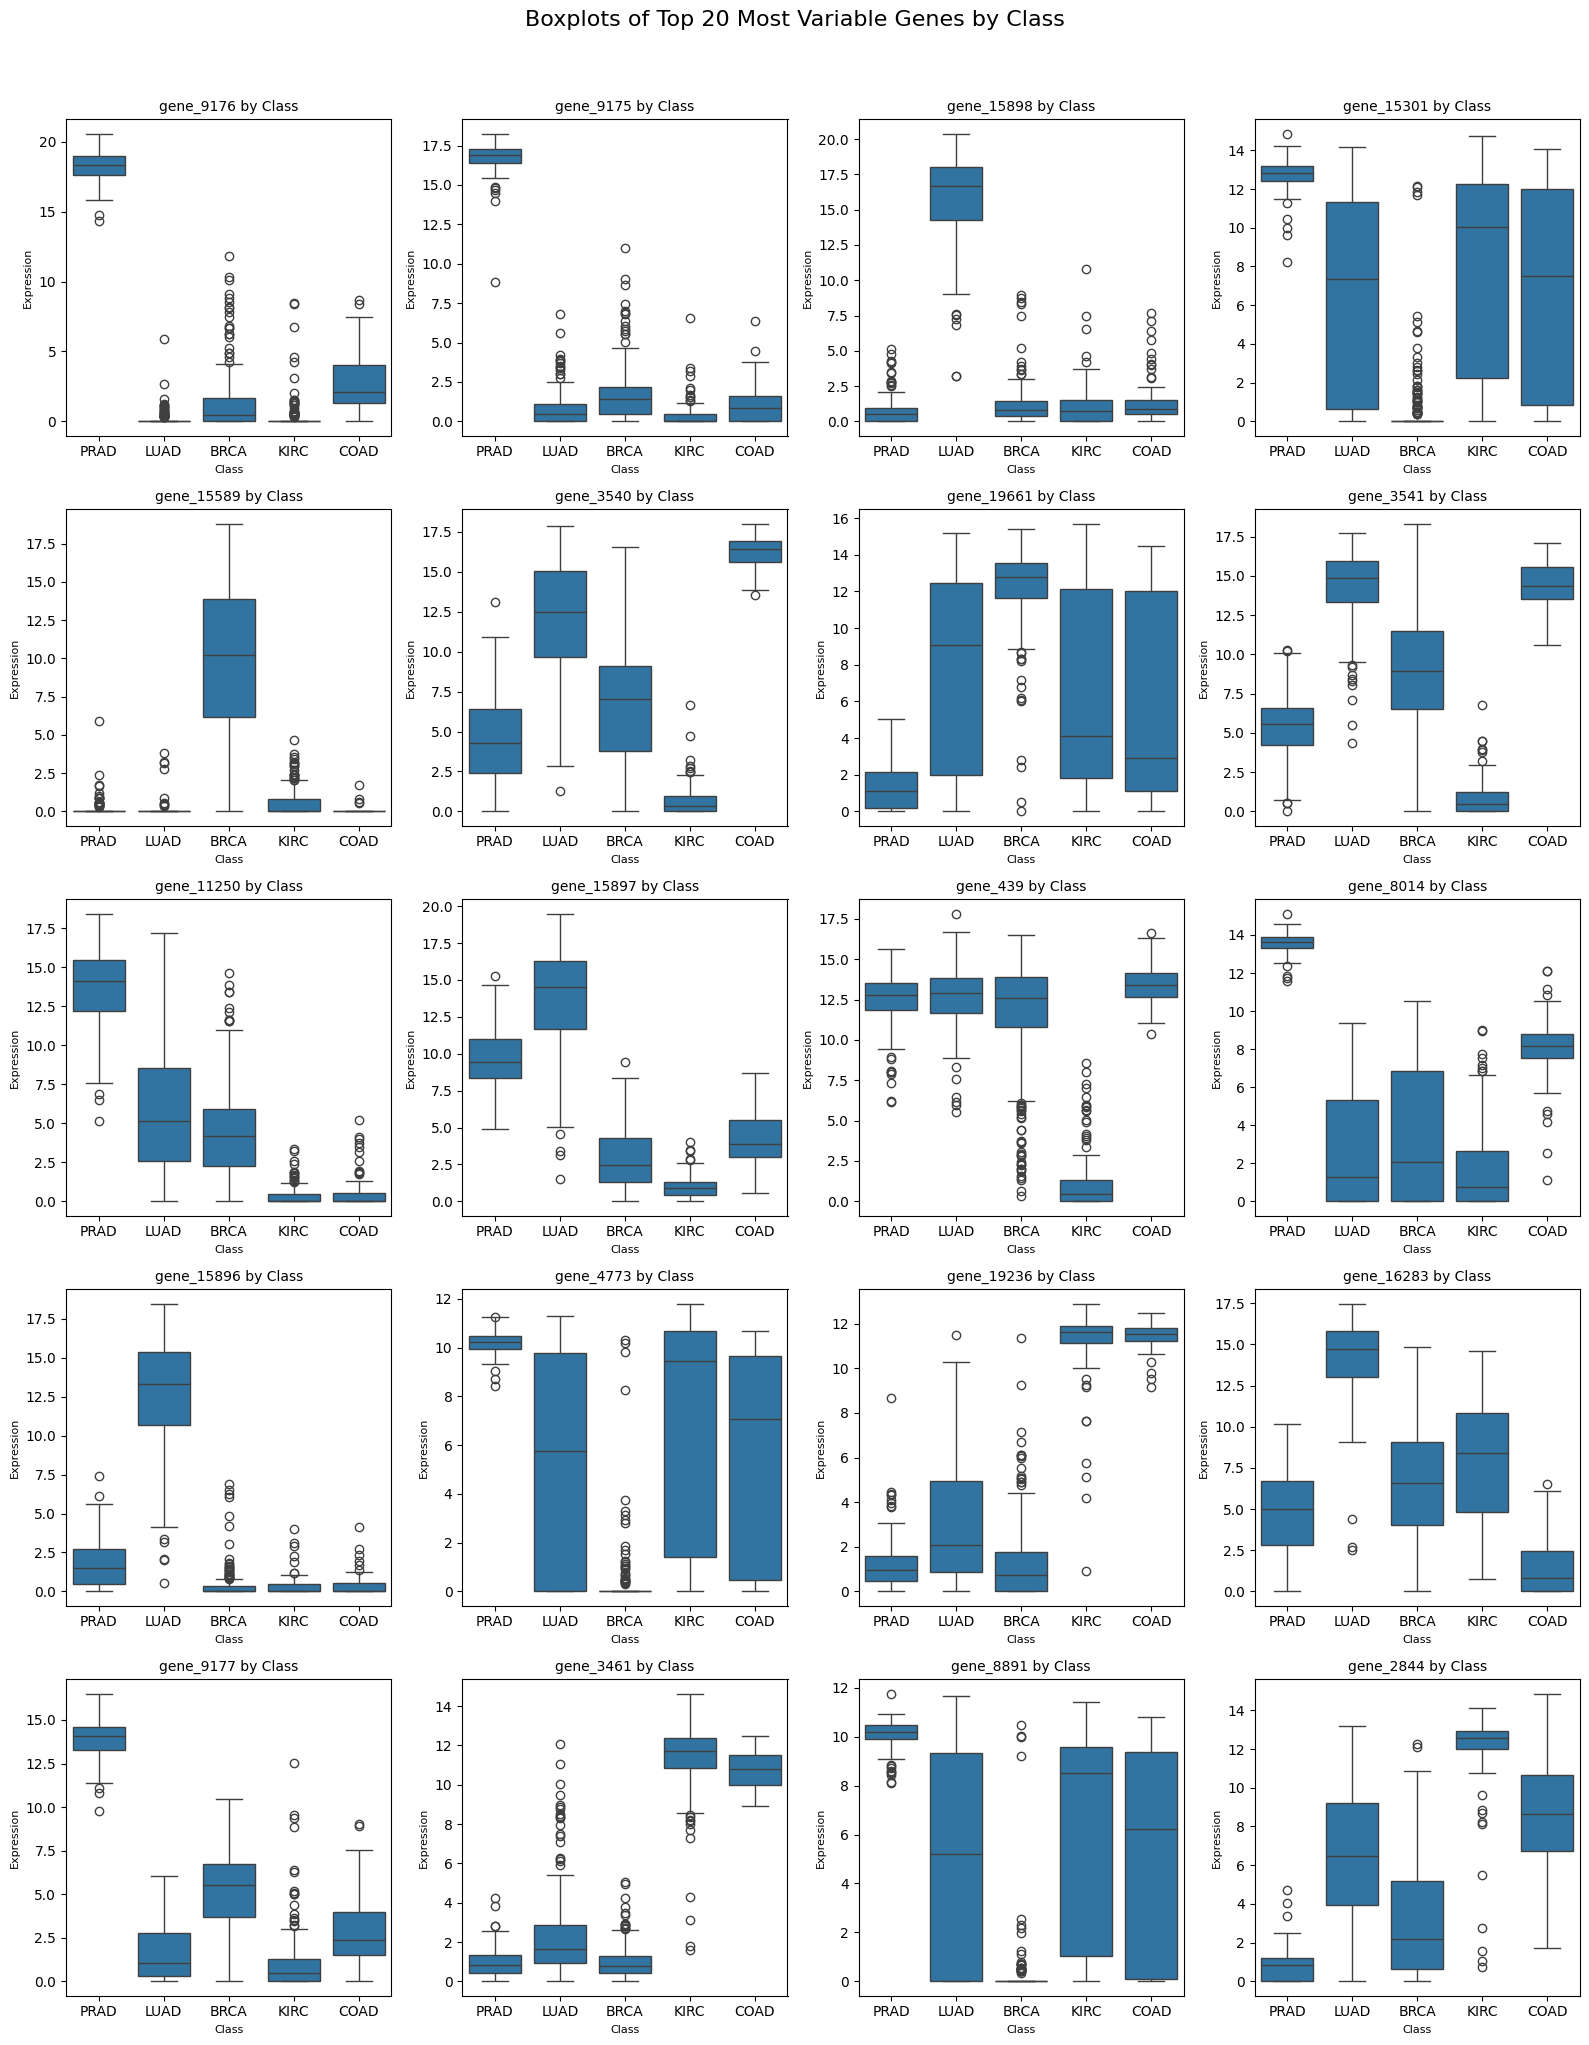

In [67]:
fig, axes = plt.subplots(nrows=5, ncols=4, figsize=(16, 20))
axes = axes.flatten()
for i, gene in enumerate(top_20_genes):
    sns.boxplot(x='Class', y=gene, data=df_top20, ax=axes[i])
    
    axes[i].set_title(f'{gene} by Class', fontsize=10)
    axes[i].set_xlabel('Class', fontsize=8)
    axes[i].set_ylabel('Expression', fontsize=8)
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)
plt.suptitle('Boxplots of Top 20 Most Variable Genes by Class', fontsize=16, y=1.02)    
plt.tight_layout()
plt.savefig('/Users/meschacolongo/gene-expression-analysis/pictures/top20_gene_boxplots.png', bbox_inches='tight')
plt.show()

### Group Comparison Findings

Genes 3541, 3540, 15897 show the clearest separation across cancer types and represent potential biomarker candidates. BRCA consistently shows distinct expression patterns compared to other cancer types.

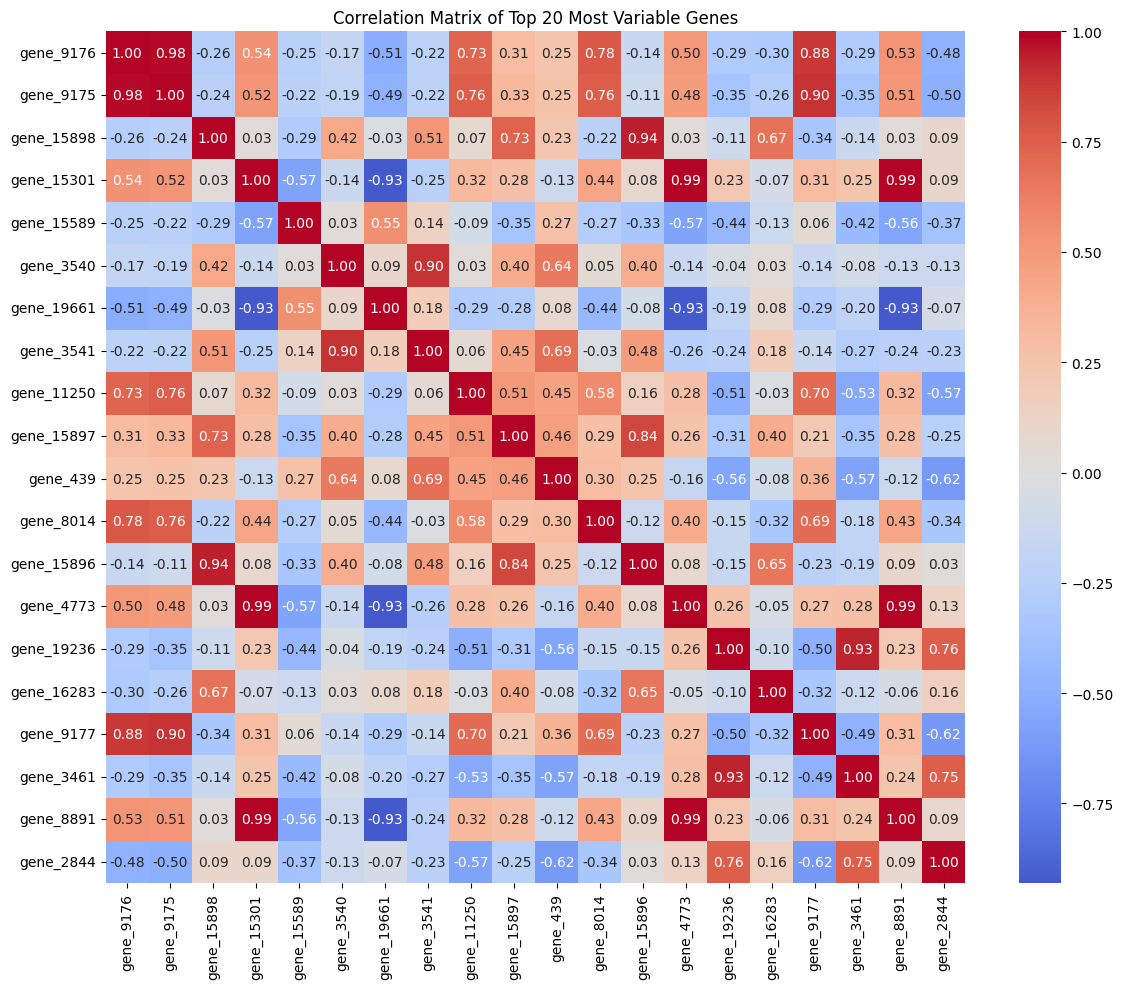

In [71]:
corr_matrix = X_top20.corr()
plt.figure(figsize=(12, 10))
sns.heatmap(
    corr_matrix, 
    annot=True, 
    fmt=".2f", 
    center=0,
    cmap='coolwarm', 
    cbar=True)
plt.title('Correlation Matrix of Top 20 Most Variable Genes')
plt.tight_layout()
plt.savefig('/Users/meschacolongo/gene-expression-analysis/pictures/top20_gene_correlation_matrix.png', bbox_inches='tight')
plt.show()

### Correlation Analysis of Key Genes and Summary of Key Findings

A dataset of **801 samples** containing **20,531 genes** was analyzed to explore whether gene expression patterns from RNA-seq data can distinguish between different cancer types. 

To reduce dimensionality, only the **top 20 most variable genes** were selected. While this number is somewhat subjective, it provides a balance between retaining meaningful biological variation and maintaining analytical simplicity without overwhelming the model.

The dataset exhibits **class imbalance**, with **BRCA (Breast Cancer)** being the most highly represented cancer type.

Overall, the majority of genes show **low expression levels**, with a smaller subset exhibiting **high expression**, consistent with typical RNA-seq data distributions.

Genes **4773**, **8891**, and **15301** form a tightly correlated cluster (*r = 0.99*), indicating that their expression levels move almost in perfect synchrony across all samples.

In bioinformatics, such a strong positive correlation often suggests that these genes:
- Belong to the same biological pathway  
- Are regulated by a common transcription factor  
- May represent redundant features that could be reduced to a single variable in a machine learning pipeline  

In contrast, **gene 19661** shows a strong negative correlation with this cluster (*r = -0.93*). This inverse relationship indicates that when genes 4773, 8891, and 15301 are highly expressed, gene 19661 is consistently suppressed, and vice versa.

This opposing expression pattern is biologically significant and may reflect **competing regulatory mechanisms**, a phenomenon commonly observed in cancer biology.

### Research Question
**What are these genes, and which biological pathways do they belong to?**